# Customer Churn Prediction


## 1. Import Libraries

In [21]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)

## 2. Locate and Load Dataset


In [22]:
NOTEBOOK_DIR = Path.cwd()
DATASET_DIR = (NOTEBOOK_DIR / ".." / "datasets").resolve()

print("Current notebook directory:", NOTEBOOK_DIR)
print("Expected dataset directory:", DATASET_DIR)

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_DIR}\n"
        "Create the folder and place Churn_Modelling.csv inside it."
    )

csv_files = sorted(DATASET_DIR.glob("*.csv"))
print("CSV files found:", [file.name for file in csv_files])

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATASET_DIR}")

Current notebook directory: c:\Users\bhard\CODSOFT\Customer Churn\code file
Expected dataset directory: C:\Users\bhard\CODSOFT\Customer Churn\datasets
CSV files found: ['Churn_Modelling.csv']


In [23]:
preferred_file = DATASET_DIR / "Churn_Modelling.csv"

if preferred_file.exists():
    data_path = preferred_file
else:
    data_path = csv_files[0]
    print(f"Churn_Modelling.csv not found. Loading {data_path.name} instead.")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Basic Data Audit

In [24]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:


,dtype
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64



Missing values:


,missing_count
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0



Duplicate rows: 0


Target column: Exited


,count
Exited,
0,7963
1,2037


Churn rate: 20.37%


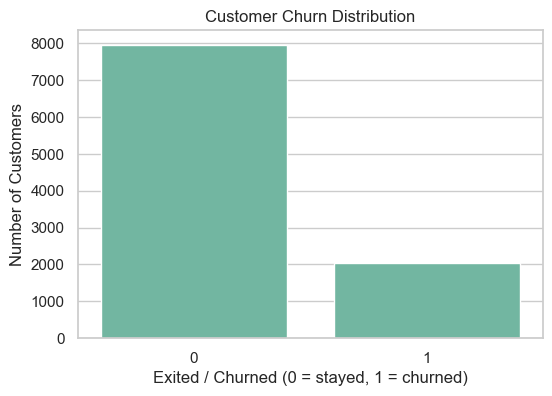

In [25]:
target_col = "Exited"

if target_col not in df.columns:
    possible_targets = ["churn", "Churn", "Exited", "exit", "Exit"]
    matches = [col for col in possible_targets if col in df.columns]
    if matches:
        target_col = matches[0]
    else:
        raise ValueError("Could not find churn target column. Expected 'Exited'.")

print("Target column:", target_col)

target_counts = df[target_col].value_counts().sort_index()
display(target_counts.to_frame("count"))
print(f"Churn rate: {df[target_col].mean() * 100:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title("Customer Churn Distribution")
plt.xlabel("Exited / Churned (0 = stayed, 1 = churned)")
plt.ylabel("Number of Customers")
plt.show()

## 4. Exploratory Data Analysis

In [26]:
numeric_summary = df.select_dtypes(include=["number"]).describe().T
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


,count,mean
Geography,,
Germany,2509,0.324432
Spain,2477,0.166734
France,5014,0.161548


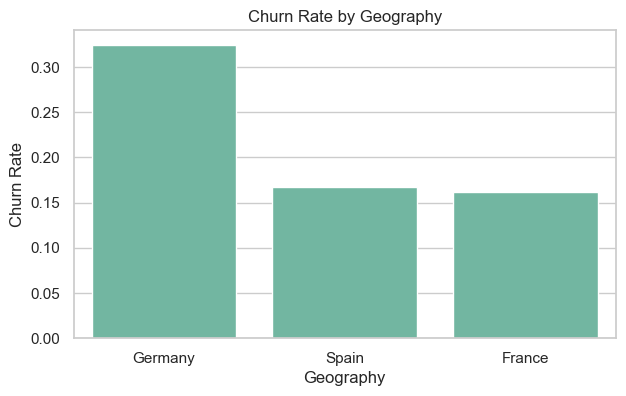

,count,mean
Gender,,
Female,4543,0.250715
Male,5457,0.164559


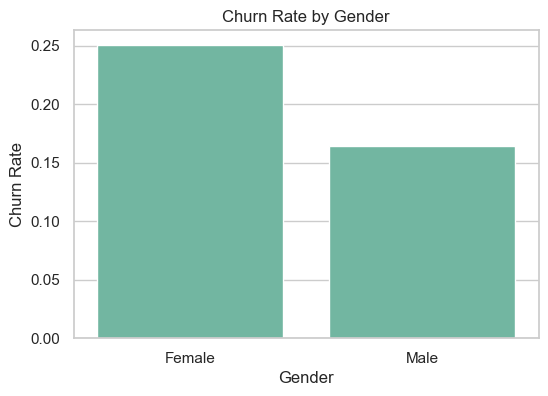

In [27]:
if "Geography" in df.columns:
    geography_churn = df.groupby("Geography")[target_col].agg(["count", "mean"]).sort_values("mean", ascending=False)
    display(geography_churn)
    
    plt.figure(figsize=(7, 4))
    sns.barplot(data=geography_churn.reset_index(), x="Geography", y="mean")
    plt.title("Churn Rate by Geography")
    plt.xlabel("Geography")
    plt.ylabel("Churn Rate")
    plt.show()

if "Gender" in df.columns:
    gender_churn = df.groupby("Gender")[target_col].agg(["count", "mean"]).sort_values("mean", ascending=False)
    display(gender_churn)
    
    plt.figure(figsize=(6, 4))
    sns.barplot(data=gender_churn.reset_index(), x="Gender", y="mean")
    plt.title("Churn Rate by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Churn Rate")
    plt.show()

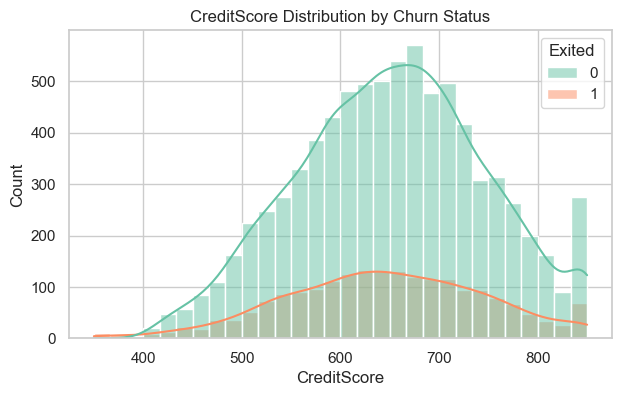

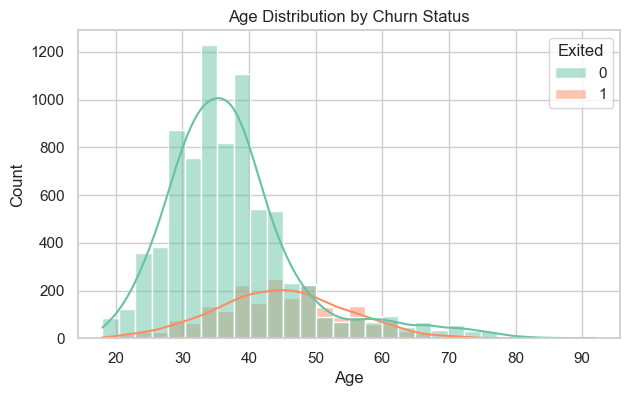

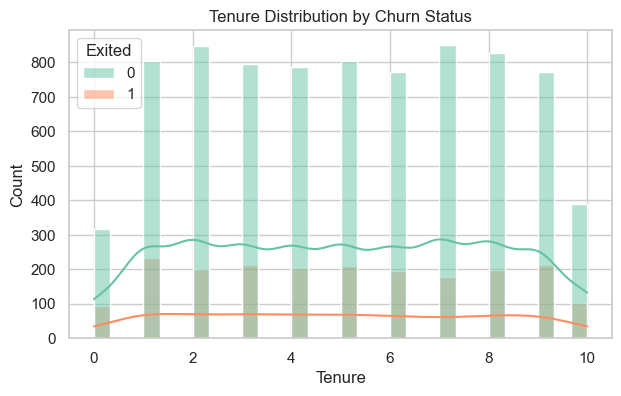

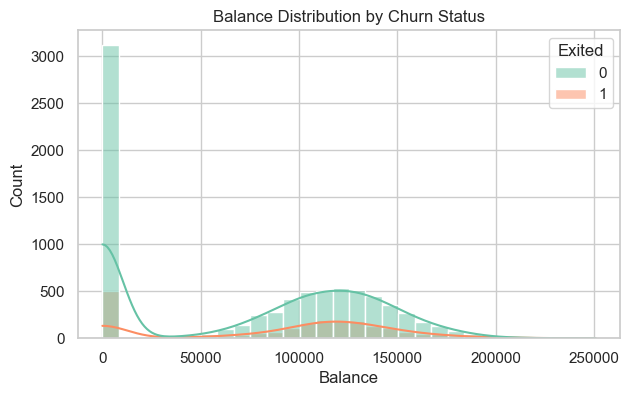

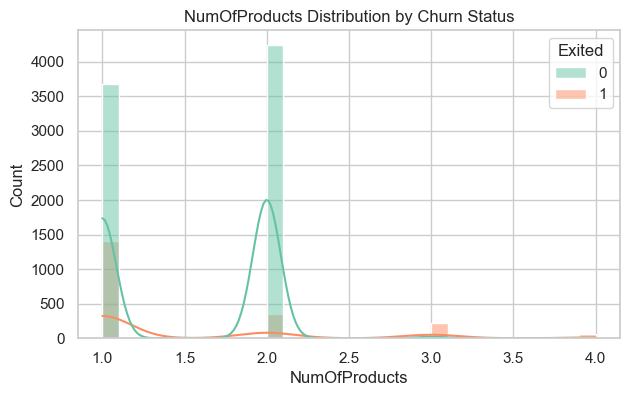

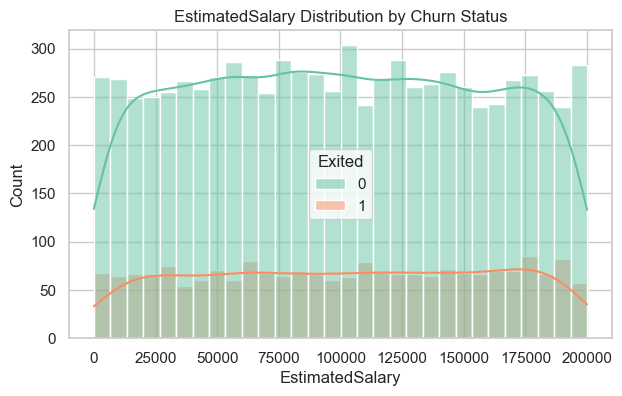

In [28]:
important_numeric = [col for col in ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"] if col in df.columns]

for col in important_numeric:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue=target_col, kde=True, bins=30, common_norm=False)
    plt.title(f"{col} Distribution by Churn Status")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

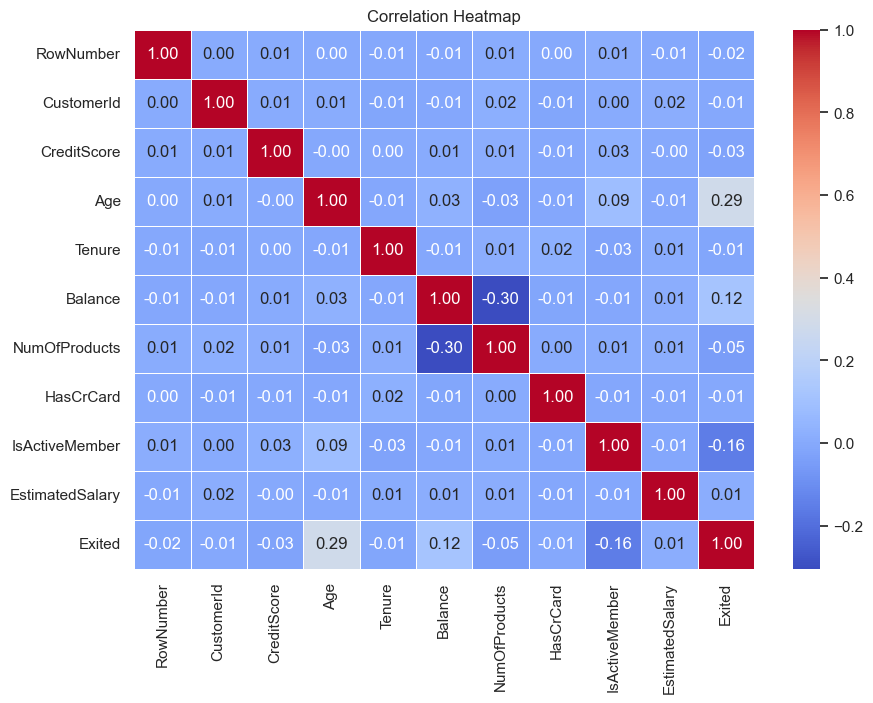

In [29]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=["number"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## 5. Prepare Features


In [30]:
drop_cols = ["RowNumber", "CustomerId", "Surname"]
existing_drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=existing_drop_cols + [target_col])
y = df[target_col].astype(int)

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Dropped columns:", existing_drop_cols)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
display(X.head())

Dropped columns: ['RowNumber', 'CustomerId', 'Surname']
Numeric features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical features: ['Geography', 'Gender']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training churn ratio:")
print(y_train.value_counts(normalize=True).rename("ratio"))

Train shape: (8000, 10)
Test shape: (2000, 10)
Training churn ratio:
Exited
0    0.79625
1    0.20375
Name: ratio, dtype: float64


## 6. Preprocessing Pipeline

In [32]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

## 7. Train Models


In [33]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=180,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

print("Training complete.")

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training complete.


## 8. Evaluate Models


In [34]:
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        raw_scores = model.decision_function(X)
        return (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
    return model.predict(X)


evaluation_rows = []

for name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)
    y_score = get_scores(pipeline, X_test)
    
    evaluation_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_score),
            "pr_auc": average_precision_score(y_test, y_score),
        }
    )

evaluation_df = pd.DataFrame(evaluation_rows).sort_values("f1", ascending=False)
display(evaluation_df)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Random Forest,0.8095,0.522727,0.734644,0.610827,0.859979,0.684208
2,Gradient Boosting,0.8700,0.790514,0.491400,0.606061,0.869655,0.718738
0,Logistic Regression,0.7135,0.387228,0.700246,0.498688,0.777165,0.467919


Best model based on F1-score: Random Forest
              precision    recall  f1-score   support

      Stayed       0.92      0.83      0.87      1593
     Churned       0.52      0.73      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



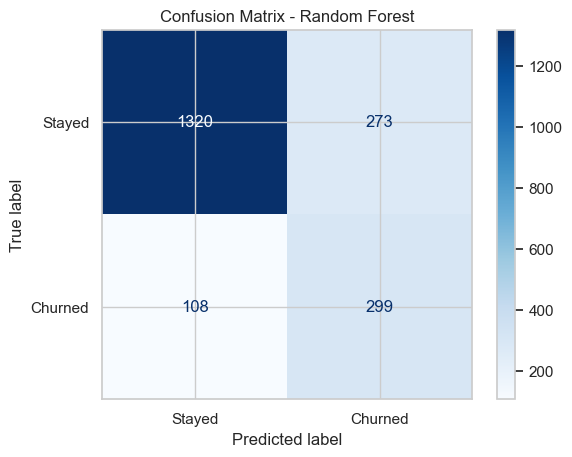

In [35]:
best_model_name = evaluation_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model based on F1-score:", best_model_name)

y_pred_best = best_model.predict(X_test)
y_score_best = get_scores(best_model, X_test)

print(classification_report(y_test, y_pred_best, target_names=["Stayed", "Churned"], zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

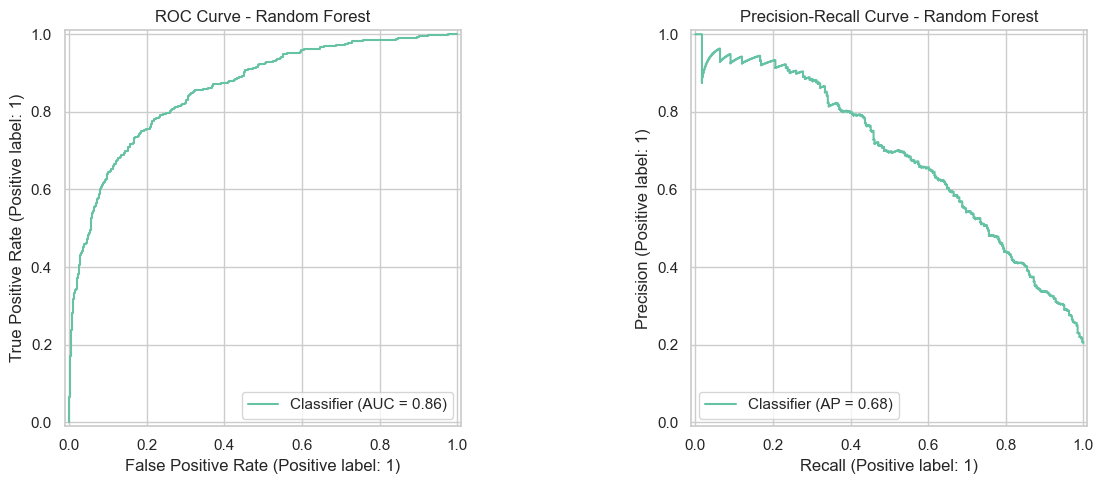

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_test, y_score_best, ax=axes[0])
axes[0].set_title(f"ROC Curve - {best_model_name}")

PrecisionRecallDisplay.from_predictions(y_test, y_score_best, ax=axes[1])
axes[1].set_title(f"Precision-Recall Curve - {best_model_name}")

plt.tight_layout()
plt.show()

## 9. Tune the Churn Probability Threshold


,threshold,precision,recall,f1
10,0.60,0.637056,0.616708,0.626717
9,0.55,0.577083,0.680590,0.624577
11,0.65,0.683891,0.552826,0.611413
8,0.50,0.522727,0.734644,0.610827
7,0.45,0.471810,0.781327,0.588344
12,0.70,0.730469,0.459459,0.564103
6,0.40,0.413879,0.820639,0.550247
5,0.35,0.371339,0.872236,0.520910
13,0.75,0.801020,0.385749,0.520730
4,0.30,0.330365,0.911548,0.484967


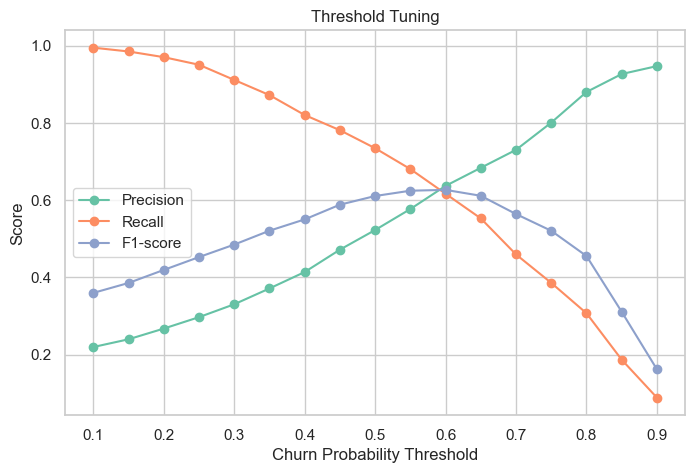

In [37]:
threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    y_pred_threshold = (y_score_best >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": round(float(threshold), 2),
            "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
            "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
            "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.sort_values("f1", ascending=False).head(10))

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1-score")
plt.xlabel("Churn Probability Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

## 10. Feature Importance

,feature,importance
1,num__Age,0.347620
4,num__NumOfProducts,0.214612
3,num__Balance,0.107146
6,num__IsActiveMember,0.062192
7,num__EstimatedSalary,0.059601
0,num__CreditScore,0.058484
9,cat__Geography_Germany,0.050689
2,num__Tenure,0.034568
8,cat__Geography_France,0.016729
12,cat__Gender_Male,0.015219


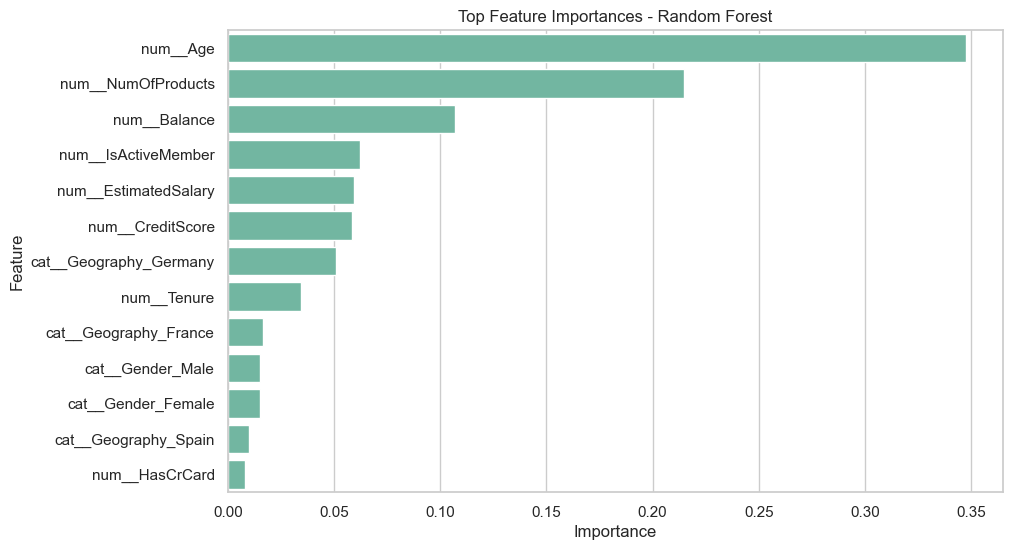

In [38]:
final_estimator = best_model.named_steps["model"]

try:
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
except Exception:
    feature_names = np.array(X_train.columns)

if hasattr(final_estimator, "feature_importances_"):
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": final_estimator.feature_importances_,
        }
    ).sort_values("importance", ascending=False)
    
    display(importance_df.head(20))
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(20), x="importance", y="feature")
    plt.title(f"Top Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print(f"{best_model_name} does not expose tree-style feature_importances_.")

## 11. Save the Best Model

In [39]:
MODEL_DIR = (NOTEBOOK_DIR / "models").resolve()
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "customer_churn_best_model.joblib"
joblib.dump(best_model, model_path)

print("Saved model to:", model_path)

Saved model to: C:\Users\bhard\CODSOFT\Customer Churn\code file\models\customer_churn_best_model.joblib


## 12. Single Prediction Example

In [40]:
sample_customer = X_test.iloc[[0]]
churn_probability = best_model.predict_proba(sample_customer)[0, 1]
churn_prediction = int(churn_probability >= 0.50)

print("Churn probability:", round(float(churn_probability), 4))
print("Predicted class:", churn_prediction, "(1 = churned, 0 = stayed)")
display(sample_customer)

Churn probability: 0.1314
Predicted class: 0 (1 = churned, 0 = stayed)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
5702,585,France,Male,36,7,0.0,2,1,0,94283.09


## Conclusion

This notebook built a complete customer churn prediction workflow:

- Loaded the official Codsoft/Kaggle bank churn dataset.
- Audited data quality and target distribution.
- Explored churn patterns by customer demographics and banking behavior.
- Preprocessed numeric and categorical features.
- Trained Logistic Regression, Random Forest, and Gradient Boosting models.
- Evaluated models with imbalance-aware classification metrics.
- Tuned the prediction threshold and saved the best model.
